# Aula 05 — PSO

Implementação simples e organizada das quatro missões do roteiro e do Relatório Final PSO. Os experimentos usam sementes fixas para serem reproduzíveis.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display

plt.style.use("seaborn-v0_8-whitegrid")

## Missão 1 — Partícula solitária

Minimizar `f(x) = x²` em `[-10, 10]`.

Inicial: x=0.2364 (fitness=0.0559)
Melhor: x=0.030274 | fitness=0.00091649


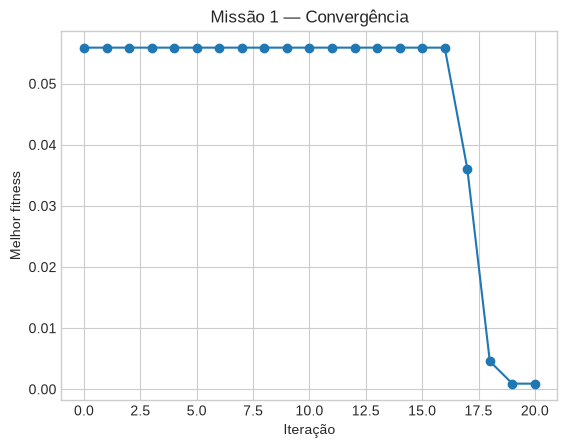

In [2]:
rng = np.random.default_rng(1)
W, C1, C2, LIMITE = 0.8, 1.5, 1.5, 10

def f(x): return x**2

pos = rng.uniform(-LIMITE, LIMITE)
vel = rng.uniform(-1, 1)
pbest, pbest_f = pos, f(pos)
gbest, gbest_f = pos, f(pos)
hist = [gbest_f]

for _ in range(20):
    vel = W*vel + C1*rng.random()*(pbest-pos) + C2*rng.random()*(gbest-pos)
    pos = np.clip(pos+vel, -LIMITE, LIMITE)
    atual = f(pos)
    if atual < pbest_f: pbest, pbest_f = pos, atual
    if atual < gbest_f: gbest, gbest_f = pos, atual
    hist.append(gbest_f)

print(f"Inicial: x={hist[0]**0.5:.4f} (fitness={hist[0]:.4f})")
print(f"Melhor: x={gbest:.6f} | fitness={gbest_f:.8f}")
plt.plot(hist, marker='o'); plt.title('Missão 1 — Convergência'); plt.xlabel('Iteração'); plt.ylabel('Melhor fitness'); plt.show()

## Missão 2 — Enxame na função de Rosenbrock

Minimizar `(1-x)² + 100(y-x²)²`, cujo ótimo global é `(1, 1)`.

Melhor posição: (0.999836, 0.999418)
Fitness: 0.00000645 | distância até (1,1): 0.000605


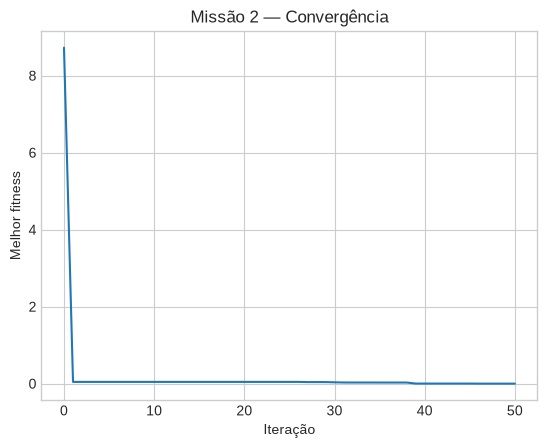

In [3]:
rng = np.random.default_rng(2)
N, T, W, C1, C2 = 20, 50, 0.7, 1.8, 1.8

def rosen(p):
    x, y = p; return (1-x)**2 + 100*(y-x**2)**2

pos = rng.uniform([-2,-1], [2,3], (N,2))
vel = rng.uniform(-.5,.5, (N,2))
pbest = pos.copy(); pfit = np.array([rosen(p) for p in pos])
i = pfit.argmin(); gbest, gfit = pos[i].copy(), pfit[i]
hist = [gfit]

for _ in range(T):
    for i in range(N):
        vel[i] = W*vel[i] + C1*rng.random(2)*(pbest[i]-pos[i]) + C2*rng.random(2)*(gbest-pos[i])
        pos[i] = np.clip(pos[i]+vel[i], [-2,-1], [2,3])
        fit = rosen(pos[i])
        if fit < pfit[i]: pbest[i], pfit[i] = pos[i].copy(), fit
        if fit < gfit: gbest, gfit = pos[i].copy(), fit
    hist.append(gfit)

print(f"Melhor posição: ({gbest[0]:.6f}, {gbest[1]:.6f})")
print(f"Fitness: {gfit:.8f} | distância até (1,1): {np.linalg.norm(gbest-[1,1]):.6f}")
plt.plot(hist); plt.title('Missão 2 — Convergência'); plt.xlabel('Iteração'); plt.ylabel('Melhor fitness'); plt.show()

## Missão 3 — Localização dos centros de distribuição

O custo é a soma de `distância × demanda`, usando o centro mais próximo de cada cliente. O objetivo é minimizar o custo positivo.

Custo inicial: 4159.95
Custo final: 3314.91 | melhoria: 20.31%
Centro 1: (5.704, 7.765)
Centro 2: (7.521, 2.752)
Centro 3: (8.366, 7.131)
Centro 4: (1.595, 5.151)
Centro 5: (4.437, 2.275)


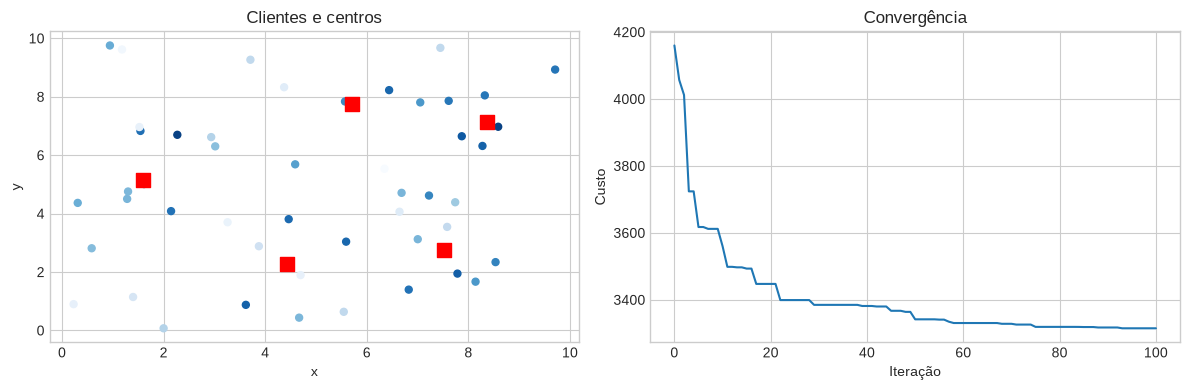

In [4]:
rng = np.random.default_rng(42)
clientes = rng.random((50,2))*10
demandas = rng.integers(1,100,50)
N, T, K, W, C1, C2 = 30, 100, 5, 0.7, 1.8, 1.8

def custo(pos):
    centros = pos.reshape(K,2)
    dist = np.linalg.norm(clientes[:,None,:]-centros[None,:,:], axis=2)
    return np.sum(np.min(dist,axis=1)*demandas)

pos = rng.uniform(0,10,(N,K*2)); vel = rng.uniform(-.5,.5,(N,K*2))
pbest = pos.copy(); pfit = np.array([custo(p) for p in pos])
i = pfit.argmin(); gbest, gfit = pos[i].copy(), pfit[i]
custo_inicial = gfit; hist = [gfit]

for _ in range(T):
    for i in range(N):
        vel[i] = W*vel[i] + C1*rng.random(K*2)*(pbest[i]-pos[i]) + C2*rng.random(K*2)*(gbest-pos[i])
        pos[i] = np.clip(pos[i]+vel[i], 0, 10)
        fit = custo(pos[i])
        if fit < pfit[i]: pbest[i], pfit[i] = pos[i].copy(), fit
        if fit < gfit: gbest, gfit = pos[i].copy(), fit
    hist.append(gfit)

centros = gbest.reshape(K,2)
print(f"Custo inicial: {custo_inicial:.2f}")
print(f"Custo final: {gfit:.2f} | melhoria: {(1-gfit/custo_inicial)*100:.2f}%")
for i,(x,y) in enumerate(centros,1): print(f"Centro {i}: ({x:.3f}, {y:.3f})")
fig,ax=plt.subplots(1,2,figsize=(12,4))
ax[0].scatter(clientes[:,0],clientes[:,1],c=demandas,cmap='Blues',s=25); ax[0].scatter(centros[:,0],centros[:,1],c='red',marker='s',s=100)
ax[0].set(title='Clientes e centros',xlabel='x',ylabel='y')
ax[1].plot(hist); ax[1].set(title='Convergência',xlabel='Iteração',ylabel='Custo')
plt.tight_layout(); plt.show()

## Missão 4 — Comparação de parâmetros

Cada configuração é executada cinco vezes. A escolha é feita pelo menor custo médio.

In [5]:
base = dict(n=30, t=50, w=.7, c1=1.8, c2=1.8)
experimentos = {
    'Padrão': base, 'Inércia alta': {**base,'w':.9}, 'Inércia baixa': {**base,'w':.5},
    'Cognitivo alto': {**base,'c1':2.5}, 'Social alto': {**base,'c2':2.5},
    'Mais partículas': {**base,'n':60}
}
rng = np.random.default_rng(42); clientes4=rng.random((50,2))*10; demandas4=rng.integers(1,100,50)

def executa(p, seed):
    r=np.random.default_rng(seed); d=10; K=5
    def fit(v):
        c=v.reshape(K,2); dist=np.linalg.norm(clientes4[:,None,:]-c[None,:,:],axis=2)
        return np.sum(np.min(dist,axis=1)*demandas4)
    x=r.uniform(0,10,(p['n'],d)); v=r.uniform(-.5,.5,(p['n'],d)); pb=x.copy(); pf=np.array([fit(a) for a in x])
    j=pf.argmin(); gb=x[j].copy(); gf=pf[j]
    for _ in range(p['t']):
        for j in range(p['n']):
            v[j]=p['w']*v[j]+p['c1']*r.random(d)*(pb[j]-x[j])+p['c2']*r.random(d)*(gb-x[j])
            x[j]=np.clip(x[j]+v[j],0,10); fnow=fit(x[j])
            if fnow<pf[j]: pb[j],pf[j]=x[j].copy(),fnow
            if fnow<gf: gb,gf=x[j].copy(),fnow
    return gf

linhas=[]
for k,(nome,p) in enumerate(experimentos.items()):
    valores=[executa(p,100+k*10+i) for i in range(5)]
    linhas.append([nome,np.mean(valores),np.std(valores),min(valores),max(valores)])
resultado = __import__('pandas').DataFrame(linhas,columns=['Experimento','Custo médio','Desvio-padrão','Melhor','Pior']).set_index('Experimento')
display(resultado.round(2))
print('Melhor configuração:', resultado['Custo médio'].idxmin())
print('Pior configuração:', resultado['Custo médio'].idxmax())

,Custo médio,Desvio-padrão,Melhor,Pior
Experimento,,,,
Padrão,3392.33,66.40,3314.07,3474.93
Inércia alta,3794.50,115.43,3697.04,3938.49
Inércia baixa,3362.19,106.82,3234.26,3486.93
Cognitivo alto,3707.95,166.48,3530.38,4014.21
Social alto,3654.08,129.80,3517.54,3880.96
Mais partículas,3346.75,112.83,3258.59,3566.48


Melhor configuração: Mais partículas
Pior configuração: Inércia alta


## Relatório Final PSO

### 1. O que é PSO?
PSO é uma técnica de inteligência coletiva na qual partículas representam soluções candidatas. Cada partícula atualiza sua velocidade usando a inércia, sua melhor posição pessoal (`pBest`) e a melhor posição do grupo (`gBest`). Em seguida, ela atualiza sua posição e é avaliada novamente.

### 2. Diferença entre `pBest` e `gBest`
`pBest` é a melhor solução encontrada por uma partícula. `gBest` é a melhor solução encontrada por todo o enxame. O `pBest` mantém a experiência individual e o `gBest` orienta a cooperação entre as partículas.

### 3. Respostas das missões
A Missão 1 executa 20 iterações, mas a partícula solitária pode não chegar ao mínimo global porque não existe diversidade nem cooperação. A Missão 2 encontra uma solução muito próxima de `(1,1)`, mostrando a vantagem do enxame. Na Missão 3, o custo final é menor que o inicial e são alocados cinco centros. A Missão 4 apresenta a comparação numérica das configurações na tabela gerada pelo notebook.

### 4. Análise dos parâmetros
A inércia alta aumenta a exploração, mas pode dificultar a estabilização. A inércia baixa favorece o refinamento local. Valores altos de `c1` tornam a busca mais individualista, enquanto valores altos de `c2` aumentam a atração pelo melhor global. Mais partículas aumentam a diversidade, porém também elevam o custo computacional. A configuração recomendada é a que obtiver o menor custo médio na tabela da Missão 4.

### 5. Experiência
A principal dificuldade foi implementar corretamente a atualização vetorial e manter a função de custo com a convenção de minimização. A atividade mostrou que a combinação de memória individual e informação social permite resolver tanto funções matemáticas quanto um problema de localização logística.